In [1]:
import pandas as pd


In [2]:
df_prop=pd.read_csv("../data/Raw/properties_2016.csv")
df_train=pd.read_csv("../data/Raw/train_2016_v2.csv")
df_prop.tail()

C:\Users\DELL\AppData\Local\Temp\ipykernel_8240\3406481020.py:1: DtypeWarning: Columns (22,32,34,49,55) have mixed types. Specify dtype option on import or set low_memory=False.
  df_prop=pd.read_csv("../data/Raw/properties_2016.csv")


,parcelid,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,buildingqualitytypeid,calculatedbathnbr,decktypeid,...,numberofstories,fireplaceflag,structuretaxvaluedollarcnt,taxvaluedollarcnt,assessmentyear,landtaxvaluedollarcnt,taxamount,taxdelinquencyflag,taxdelinquencyyear,censustractandblock
2985212,168176230,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2985213,14273630,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2985214,168040630,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2985215,168040830,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2985216,168040430,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:

df_train.head()

,parcelid,logerror,transactiondate
0,11016594,0.0276,2016-01-01
1,14366692,-0.1684,2016-01-01
2,12098116,-0.0040,2016-01-01
3,12643413,0.0218,2016-01-02
4,14432541,-0.0050,2016-01-02


In [4]:
print(f"shape of properties table:{df_prop.shape}")
print(f"shape of training table:{df_train.shape}")

shape of properties table:(2985217, 58)
shape of training table:(90275, 3)


In [5]:
df_merged=df_train.merge(df_prop,on="parcelid",how="left")
print(f"shape of merged table:{df_merged.shape}")

shape of merged table:(90275, 60)


In [6]:
df_merged.columns[:10]

Index(['parcelid', 'logerror', 'transactiondate', 'airconditioningtypeid',
       'architecturalstyletypeid', 'basementsqft', 'bathroomcnt', 'bedroomcnt',
       'buildingclasstypeid', 'buildingqualitytypeid'],
      dtype='object')

In [7]:
import numpy as np
from sklearn.metrics import pairwise
mean_lat=np.mean(df_merged["latitude"])
mean_long=np.mean(df_merged["longitude"])
df_merged["distance_from_mean"]=pairwise.haversine_distances(np.radians(df_merged[["latitude","longitude"]]),np.radians([[mean_lat,mean_long]])) * 6371000/1000
print(df_merged["distance_from_mean"].head())



0     5697.549893
1     4808.318639
2    10725.254840
3    13806.822092
4     8555.232314
Name: distance_from_mean, dtype: float64


In [8]:
df_merged.shape

(90275, 61)

In [9]:
df_merged = df_merged[
    [
        "bathroomcnt",
        "bedroomcnt",
        "calculatedfinishedsquarefeet",
        "latitude",
        "longitude",
        "distance_from_mean",
        "taxvaluedollarcnt"
        
    ]
]

In [10]:
features = [
    "bathroomcnt",
    "bedroomcnt",
    "calculatedfinishedsquarefeet",
    "latitude",
    "longitude",
    "taxvaluedollarcnt",
    "distance_from_mean"
    
    
]

df_merged[features].isnull().sum()

bathroomcnt                       0
bedroomcnt                        0
calculatedfinishedsquarefeet    661
latitude                          0
longitude                         0
taxvaluedollarcnt                 1
distance_from_mean                0
dtype: int64

In [11]:
df_clean = df_merged[features].dropna()

In [12]:
df_clean

,bathroomcnt,bedroomcnt,calculatedfinishedsquarefeet,latitude,longitude,taxvaluedollarcnt,distance_from_mean
0,2.0,3.0,1684.0,34280990.0,-118488536.0,360170.0,5697.549893
1,3.5,4.0,2263.0,33668120.0,-117677556.0,585529.0,4808.318639
2,3.0,2.0,2217.0,34136312.0,-118175032.0,119906.0,10725.254840
3,2.0,2.0,839.0,33755800.0,-118309000.0,244880.0,13806.822092
4,2.5,4.0,2283.0,33485643.0,-117700234.0,434551.0,8555.232314
...,...,...,...,...,...,...,...
90270,1.0,1.0,653.0,34203000.0,-118562000.0,191000.0,10102.721614
90271,3.0,3.0,2856.0,34198744.0,-118224849.0,161111.0,6886.034914
90272,2.0,4.0,2617.0,34075655.0,-118025537.0,38096.0,17024.515728
90273,2.0,2.0,1034.0,33963900.0,-118367000.0,165869.0,12238.981453


In [13]:
X = df_clean.drop("taxvaluedollarcnt", axis=1)
Y = df_clean["taxvaluedollarcnt"]

In [14]:
X.shape,Y.shape

((89613, 6), (89613,))

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=10)

In [17]:
print(f"Shape of test data: {X.shape},{Y_test.shape}")
print(f"Shape of train data: {X_train.shape},{Y_train.shape}")

Shape of test data: (89613, 6),(17923,)
Shape of train data: (71690, 6),(71690,)


In [18]:
X_train_coords = X_train[['latitude', 'longitude']].copy()
X_test_coords  = X_test[['latitude', 'longitude']].copy()

In [19]:
from sklearn.cluster import KMeans
kmeans=KMeans(n_clusters=20,random_state=42)
kmeans.fit(X_train_coords)
X_train["location_cluster"]=kmeans.predict(X_train_coords)
X_test["location_cluster"]=kmeans.predict(X_test_coords)

In [20]:
X_train_coords['latitude'] = X_train_coords['latitude'] / 1e6
X_train_coords['longitude'] = X_train_coords['longitude'] / 1e6

X_test_coords['latitude'] = X_test_coords['latitude'] / 1e6
X_test_coords['longitude'] = X_test_coords['longitude'] / 1e6

In [21]:
import numpy as np

X_train_coords_rad = np.radians(X_train_coords)
X_test_coords_rad  = np.radians(X_test_coords)

In [22]:
from sklearn.neighbors import NearestNeighbors
knn=NearestNeighbors(n_neighbors=50, metric='haversine')
knn.fit(X_train_coords_rad)

,n_neighbors,50
,radius,1.0
,algorithm,'auto'
,leaf_size,30
,metric,'haversine'
,p,2
,metric_params,None
,n_jobs,None


In [23]:
distances_train, indices_train = knn.kneighbors(X_train_coords_rad)
distances_test,indices_test=knn.kneighbors(X_test_coords_rad)

In [24]:
indices_train=indices_train[:,1:]
distances_train=distances_train[:,1:]
weight_train=1/(distances_train+1e-5)
weight_test=1/(distances_test+1e-5)

In [25]:
WeightedavgNeighborPrice_train=(Y_train.values[indices_train]*weight_train).sum(axis=1)/weight_train.sum(axis=1)
WeightedavgNeighborPrice_test=(Y_train.values[indices_test]*weight_test).sum(axis=1)/weight_test.sum(axis=1)

In [26]:
X_train["weighted_avg_neighbor_price"]=WeightedavgNeighborPrice_train
X_test["weighted_avg_neighbor_price"]=WeightedavgNeighborPrice_test

In [27]:
from sklearn.linear_model import LinearRegression

In [28]:
lr=LinearRegression()
lr.fit(X_train,Y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
Y_pred=lr.predict(X_test)

In [30]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [31]:
mse=mean_squared_error(Y_test,Y_pred)
mae=mean_absolute_error(Y_test,Y_pred)
r2=r2_score(Y_test,Y_pred)

In [32]:
print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R2 Score: {r2}")


Mean Absolute Error: 198552.78122876893
Mean Squared Error: 165061833363.16293
R2 Score: 0.4917075685228812


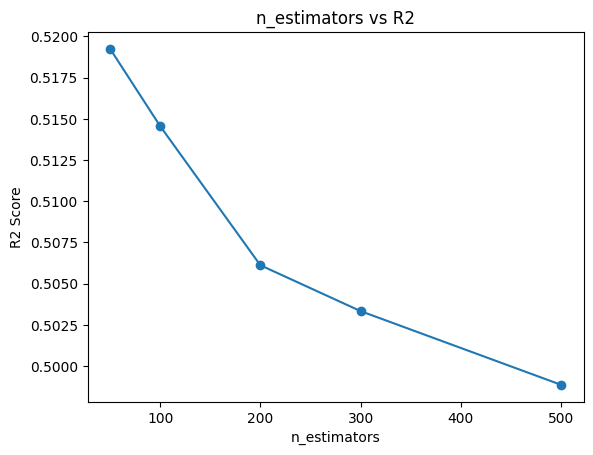

In [33]:
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

n_values = [50, 100, 200, 300, 500]
r2_scores = []

for n in n_values:
    model = XGBRegressor(
        n_estimators=n,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    
    model.fit(X_train, Y_train)
    y_pred = model.predict(X_test)
    
    r2 = r2_score(Y_test, y_pred)
    r2_scores.append(r2)

plt.plot(n_values, r2_scores, marker='o')
plt.xlabel("n_estimators")
plt.ylabel("R2 Score")
plt.title("n_estimators vs R2")
plt.show()

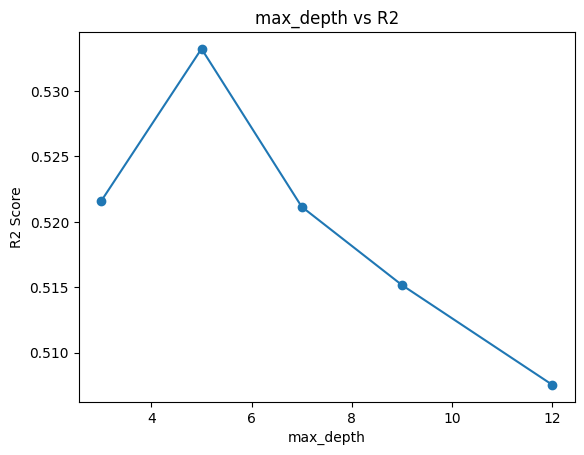

In [34]:
depth_values = [3, 5, 7, 9, 12]
r2_scores = []

for d in depth_values:
    model = XGBRegressor(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=d,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    
    model.fit(X_train, Y_train)
    y_pred = model.predict(X_test)
    
    r2_scores.append(r2_score(Y_test, y_pred))

plt.plot(depth_values, r2_scores, marker='o')
plt.xlabel("max_depth")
plt.ylabel("R2 Score")
plt.title("max_depth vs R2")
plt.show()

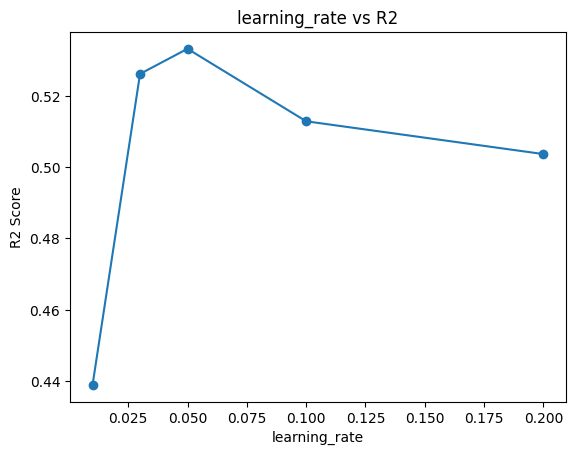

In [35]:
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.metrics import r2_score

lr_values = [0.01, 0.03, 0.05, 0.1, 0.2]
r2_scores = []

for lr in lr_values:
    model = XGBRegressor(
        n_estimators=100,      
        max_depth=5,           
        learning_rate=lr,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    
    model.fit(X_train, Y_train)
    y_pred = model.predict(X_test)
    
    r2 = r2_score(Y_test, y_pred)
    r2_scores.append(r2)

# Plot
plt.plot(lr_values, r2_scores, marker='o')
plt.xlabel("learning_rate")
plt.ylabel("R2 Score")
plt.title("learning_rate vs R2")
plt.show()

In [36]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, Y_train)
y_pred=model.predict(X_test)

In [37]:
mse=mean_squared_error(Y_test,y_pred)
mae=mean_absolute_error(Y_test,y_pred)
r2=r2_score(Y_test,y_pred)

In [38]:
print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R2 Score: {r2}")


Mean Absolute Error: 178555.10077440648
Mean Squared Error: 151577022452.552
R2 Score: 0.5332327787190094


In [39]:
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X_train.columns)
importance.sort_values(ascending=False).head(10)

weighted_avg_neighbor_price     0.370959
calculatedfinishedsquarefeet    0.213028
bathroomcnt                     0.187016
location_cluster                0.052466
latitude                        0.050742
longitude                       0.049748
distance_from_mean              0.045543
bedroomcnt                      0.030498
dtype: float32

In [40]:
X_train = X_train.drop(columns=['location_cluster'])
X_test  = X_test.drop(columns=['location_cluster'])

In [41]:
train_df = X_train.copy()
train_df["target"] = Y_train

test_df = X_test.copy()
test_df["target"] = Y_test

In [42]:
train_df.to_csv("../data/Processed/train_processed.csv", index=False)
test_df.to_csv("../data/Processed/test_processed.csv", index=False)

In [43]:
import osmnx as ox
place = "Los Angeles, California, USA"
tags = {"amenity": "school"}
schools = ox.features_from_place(place, tags)
print(schools.head())
schools.columns[:]

                                      geometry amenity  ele gnis:feature_id  \
element id                                                                    
node    358779466  POINT (-118.59272 34.24222)  school  279          238437   
        358779518  POINT (-118.20646 34.11029)  school  167          238488   
        358779550  POINT (-118.17202 34.08584)  school  158          238526   
        358779618  POINT (-118.34006 34.04309)  school   52          238557   
        358779821   POINT (-118.3073 34.25517)  school  446          238666   

                                          name  \
element id                                       
node    358779466          Aggeler High School   
        358779518     Aldama Elementary School   
        358779550            All Saints School   
        358779618  Alta Loma Elementary School   
        358779821   Apperson Elementary School   

                                              operator created_by addr:city  \
element id      

Index(['geometry', 'amenity', 'ele', 'gnis:feature_id', 'name', 'operator',
       'created_by', 'addr:city', 'addr:housenumber', 'addr:postcode',
       'addr:state', 'addr:street', 'education', 'wikidata', 'website',
       'wheelchair', 'note', 'fixme', 'phone', 'denomination', 'religion',
       'contact:phone', 'name:zh', 'toilets:wheelchair', 'alt_name',
       'operator:type', 'mascot', 'addr:suite', 'brand', 'brand:wikidata',
       'official_name', 'email', 'fax', 'addr:housename', 'source',
       'opening_hours', 'internet_access', 'short_name', 'toilets', 'grades',
       'school', 'operator:short', 'operator:wikidata', 'name:en', 'addr:unit',
       'name:etymology:wikidata', 'training', 'wikipedia', 'tourism', 'name_1',
       'operator:wikipedia', 'previously', 'not:brand:wikidata', 'source_ref',
       'not:operator:wikidata', 'start_date', 'building', 'building:levels',
       'height', 'lacounty:ain', 'lacounty:bld_id', 'check_date',
       'contact:facebook', 'contac

In [44]:
X_train["latitude"] = X_train["latitude"] / 1e6
X_train["longitude"] = X_train["longitude"] / 1e6

X_test["latitude"] = X_test["latitude"] / 1e6
X_test["longitude"] = X_test["longitude"] / 1e6

In [45]:
schools = schools[["geometry"]].copy()
schools = schools.dropna()

print(schools.shape)


(1089, 1)


In [46]:
import geopandas as gpd
X_train_geo = gpd.GeoDataFrame(
    X_train,
    geometry=gpd.points_from_xy(X_train["longitude"], X_train["latitude"])
)
X_test_geo = gpd.GeoDataFrame(
    X_test,
    geometry=gpd.points_from_xy(X_test["longitude"], X_test["latitude"])
)

In [47]:
X_train_geo.head()

,bathroomcnt,bedroomcnt,calculatedfinishedsquarefeet,latitude,longitude,distance_from_mean,weighted_avg_neighbor_price,geometry
85937,2.5,4.0,2266.0,33.833629,-117.859952,10910.789261,3.079688e+05,POINT (-117.85995 33.83363)
76520,3.0,5.0,2476.0,34.043079,-117.761973,4816.105006,2.299803e+05,POINT (-117.76197 34.04308)
18689,2.0,3.0,1671.0,34.196080,-118.561657,9233.552779,2.076915e+05,POINT (-118.56166 34.19608)
24107,2.0,4.0,2217.0,34.443771,-119.248500,6593.152222,3.991054e+05,POINT (-119.2485 34.44377)
42336,3.0,2.0,2121.0,33.614677,-117.924979,11052.312329,1.400227e+06,POINT (-117.92498 33.61468)


In [48]:
X_train_geo = X_train_geo.set_crs(epsg=4326)
X_test_geo = X_test_geo.set_crs(epsg=4326)


In [49]:

X_train_geo = X_train_geo.to_crs(epsg=3857)
X_test_geo = X_test_geo.to_crs(epsg=3857)
schools = schools.to_crs(epsg=3857)

In [50]:
import numpy as np
from tqdm import tqdm

school_counts_train = []

for house_point in tqdm(X_train_geo.geometry):
    distances = schools.geometry.distance(house_point)
    count = np.sum(distances <= 2000)  
    school_counts_train.append(count)
school_counts_test=[]
for house_point in tqdm(X_test_geo.geometry):
    distances = schools.geometry.distance(house_point)
    count = np.sum(distances <= 2000)  
    school_counts_test.append(count)
X_train_geo["school_count_2km"] = school_counts_train
X_test_geo["school_count_2km"] = school_counts_test

100%|██████████| 17923/17923 [00:12<00:00, 1380.51it/s]


In [51]:
X_train_geo["school_count_2km"].describe()


count    71690.000000
mean         2.412652
std          4.920795
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max         40.000000
Name: school_count_2km, dtype: float64

In [52]:
X_train["school_count_2km"] = X_train_geo["school_count_2km"]
X_test["school_count_2km"] = X_test_geo["school_count_2km"]

In [53]:
xgb=XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42

)
xgb.fit(X_train,Y_train)
y_pred=xgb.predict(X_test)
ae=mean_absolute_error(Y_test,y_pred)
r2=r2_score(Y_test,y_pred)
print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R2 Score: {r2}")

Mean Absolute Error: 178555.10077440648
Mean Squared Error: 151577022452.552
R2 Score: 0.5304408849074407


In [54]:
X_train.head()

,bathroomcnt,bedroomcnt,calculatedfinishedsquarefeet,latitude,longitude,distance_from_mean,weighted_avg_neighbor_price,school_count_2km
85937,2.5,4.0,2266.0,33.833629,-117.859952,10910.789261,3.079688e+05,0
76520,3.0,5.0,2476.0,34.043079,-117.761973,4816.105006,2.299803e+05,0
18689,2.0,3.0,1671.0,34.196080,-118.561657,9233.552779,2.076915e+05,11
24107,2.0,4.0,2217.0,34.443771,-119.248500,6593.152222,3.991054e+05,0
42336,3.0,2.0,2121.0,33.614677,-117.924979,11052.312329,1.400227e+06,0


In [55]:
feature_importance = pd.Series(
    xgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance.head(10))


weighted_avg_neighbor_price     0.328576
calculatedfinishedsquarefeet    0.249443
bathroomcnt                     0.170664
school_count_2km                0.066877
longitude                       0.052856
latitude                        0.051806
distance_from_mean              0.048811
bedroomcnt                      0.030967
dtype: float32


In [56]:
import osmnx as ox

tags = {"amenity": "restaurant"}

restaurants = ox.features_from_place("Los Angeles, California, USA", tags)

restaurants = restaurants[["geometry"]].dropna()

In [57]:
restaurants = restaurants.set_crs(epsg=4326)
restaurants = restaurants.to_crs(epsg=3857)

In [58]:
from tqdm import tqdm
import numpy as np

restaurant_counts = []

for house_point in tqdm(X_train_geo.geometry):
    distances = restaurants.geometry.distance(house_point)
    count = np.sum(distances <= 2000)
    restaurant_counts.append(count)

X_train_geo["restaurant_count_2km"] = restaurant_counts

100%|██████████| 71690/71690 [00:39<00:00, 1803.47it/s]


In [59]:
X_train["restaurant_count_2km"] = X_train_geo["restaurant_count_2km"]

In [60]:
restaurant_counts_test = []

for house_point in tqdm(X_test_geo.geometry):
    distances = restaurants.geometry.distance(house_point)
    count = np.sum(distances <= 2000)
    restaurant_counts_test.append(count)

X_test_geo["restaurant_count_2km"] = restaurant_counts_test
X_test["restaurant_count_2km"] = X_test_geo["restaurant_count_2km"]

100%|██████████| 17923/17923 [00:09<00:00, 1792.60it/s]


In [61]:
restaurant_counts_test = []

for house_point in tqdm(X_test_geo.geometry):
    distances = restaurants.geometry.distance(house_point)
    count = np.sum(distances <= 2000)
    restaurant_counts_test.append(count)

X_test_geo["restaurant_count_2km"] = restaurant_counts_test
X_test["restaurant_count_2km"] = X_test_geo["restaurant_count_2km"]

100%|██████████| 17923/17923 [00:10<00:00, 1712.40it/s]


In [62]:
import numpy as np

X_train["restaurant_count_2km"] = np.log1p(X_train["restaurant_count_2km"])
X_test["restaurant_count_2km"] = np.log1p(X_test["restaurant_count_2km"])

In [63]:
xgb.fit(X_train, Y_train)
y_pred = xgb.predict(X_test)

In [64]:
X_train["restaurant_count_2km"].describe()

count    71690.000000
mean         0.667099
std          1.291611
min          0.000000
25%          0.000000
50%          0.000000
75%          0.693147
max          5.605802
Name: restaurant_count_2km, dtype: float64

In [65]:
mse=mean_squared_error(Y_test,y_pred)
mae=mean_absolute_error(Y_test,y_pred)
r2=r2_score(Y_test,y_pred)
print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R2 Score: {r2}")

Mean Absolute Error: 178538.32413440483
Mean Squared Error: 154616792452.8618
R2 Score: 0.5238720921622981


In [66]:
from lightgbm import LGBMRegressor

In [67]:
lgb = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb.fit(X_train, Y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001864 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1529
[LightGBM] [Info] Number of data points in the train set: 71690, number of used features: 9
[LightGBM] [Info] Start training from score 456936.666592
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,5
,learning_rate,0.05
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [68]:
y_pred_lgb = lgb.predict(X_test)

In [69]:
from sklearn.metrics import r2_score, mean_absolute_error

r2 = r2_score(Y_test, y_pred_lgb)
mae = mean_absolute_error(Y_test, y_pred_lgb)

print("R²:", r2)
print("MAE:", mae)

R²: 0.5477814981422668
MAE: 178242.92962958847


In [70]:
import pandas as pd

feature_importance_lgb = pd.Series(
    lgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance_lgb)

weighted_avg_neighbor_price     518
calculatedfinishedsquarefeet    473
latitude                        429
longitude                       364
bathroomcnt                     314
bedroomcnt                      189
distance_from_mean              123
restaurant_count_2km            107
school_count_2km                 57
dtype: int32


In [71]:
lgb.fit(X_train, Y_train)
y_pred = lgb.predict(X_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002587 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1529
[LightGBM] [Info] Number of data points in the train set: 71690, number of used features: 9
[LightGBM] [Info] Start training from score 456936.666592
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

In [72]:
from sklearn.metrics import r2_score, mean_absolute_error

r2 = r2_score(Y_test, y_pred_lgb)
mae = mean_absolute_error(Y_test, y_pred_lgb)

print("R²:", r2)
print("MAE:", mae)

R²: 0.5477814981422668
MAE: 178242.92962958847


In [73]:
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score

num_leaves_list = [20, 30, 50, 70, 100]
r2_scores = []

for leaves in num_leaves_list:
    lgb = LGBMRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=leaves,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    
    lgb.fit(X_train, Y_train)
    y_pred = lgb.predict(X_test)
    
    r2 = r2_score(Y_test, y_pred)
    r2_scores.append(r2)
    
    print(f"num_leaves={leaves}, R²={r2}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001613 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1529
[LightGBM] [Info] Number of data points in the train set: 71690, number of used features: 9
[LightGBM] [Info] Start training from score 456936.666592
num_leaves=20, R²=0.5530273590451422
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002542 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1529
[LightGBM] [Info] Number of data points in the train set: 71690, number of used features: 9
[LightGBM] [Info] Start training from score 456936.666592
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with po

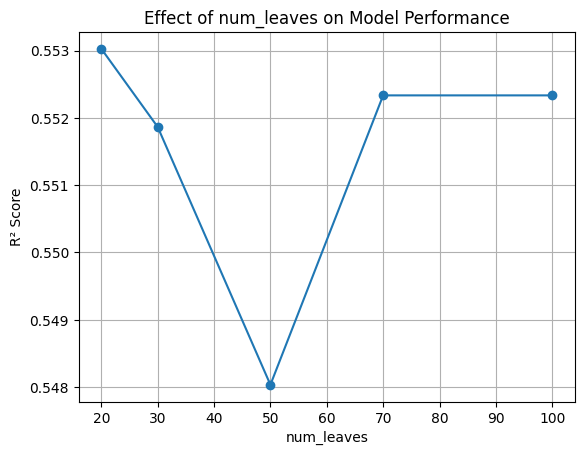

In [74]:
plt.figure()
plt.plot(num_leaves_list, r2_scores, marker='o')
plt.xlabel("num_leaves")
plt.ylabel("R² Score")
plt.title("Effect of num_leaves on Model Performance")
plt.grid()

plt.show()

In [75]:
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score

learning_rates = [0.01, 0.03, 0.05, 0.1]
r2_scores = []

for lr in learning_rates:
    lgb = LGBMRegressor(
        n_estimators=200,
        learning_rate=lr,
        max_depth=6,
        num_leaves=30,   # fixed best value
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    
    lgb.fit(X_train, Y_train)
    y_pred = lgb.predict(X_test)
    
    r2 = r2_score(Y_test, y_pred)
    r2_scores.append(r2)
    
    print(f"learning_rate={lr}, R²={r2}")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002316 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1529
[LightGBM] [Info] Number of data points in the train set: 71690, number of used features: 9
[LightGBM] [Info] Start training from score 456936.666592
learning_rate=0.01, R²=0.531912502881132
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002417 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1529
[LightGBM] [Info] Number of data points in the train set: 71690, number of used features: 9
[LightGBM] [Info] Start training from score 456936.666592
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

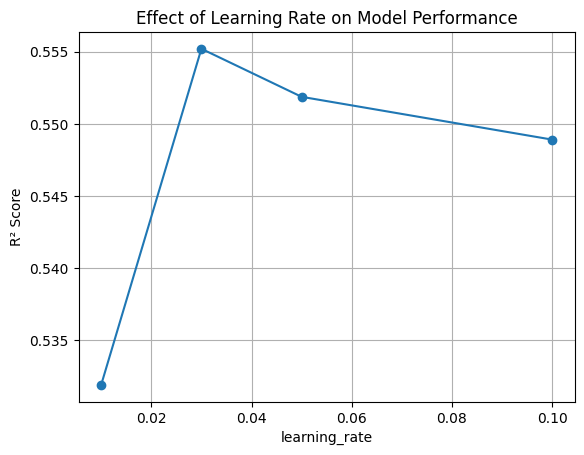

In [76]:
plt.figure()
plt.plot(learning_rates, r2_scores, marker='o')
plt.xlabel("learning_rate")
plt.ylabel("R² Score")
plt.title("Effect of Learning Rate on Model Performance")
plt.grid()

plt.show()

In [77]:
import matplotlib.pyplot as plt
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score

n_estimators_list = [100, 200, 300, 500]
r2_scores = []

for n in n_estimators_list:
    lgb = LGBMRegressor(
        n_estimators=n,
        learning_rate=0.05,
        max_depth=6,
        num_leaves=30,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )
    
    lgb.fit(X_train, Y_train)
    y_pred = lgb.predict(X_test)
    
    r2 = r2_score(Y_test, y_pred)
    r2_scores.append(r2)
    
    print(f"n_estimators={n}, R²={r2}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001821 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1529
[LightGBM] [Info] Number of data points in the train set: 71690, number of used features: 9
[LightGBM] [Info] Start training from score 456936.666592
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
n_estimators=100, R²=0.5527967309742898
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002427 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1529
[LightGBM] [Info] Number of data points in the train set: 71690, number of used features: 9
[LightGBM] [Info] Start training from score 456936.666592
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

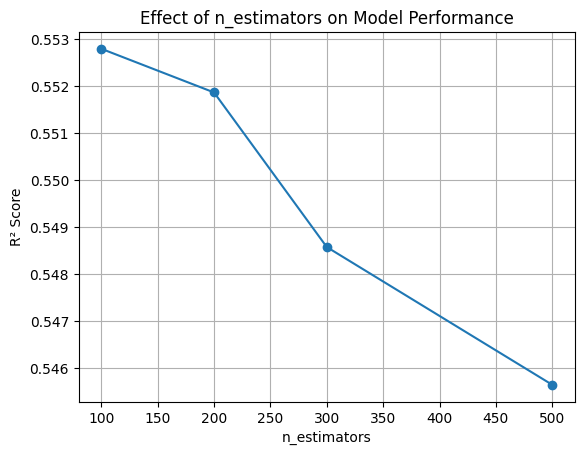

In [78]:
plt.figure()
plt.plot(n_estimators_list, r2_scores, marker='o')
plt.xlabel("n_estimators")
plt.ylabel("R² Score")
plt.title("Effect of n_estimators on Model Performance")
plt.grid()

plt.show()

In [79]:
lgb = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=30,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgb.fit(X_train, Y_train)
y_pred = lgb.predict(X_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002491 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1529
[LightGBM] [Info] Number of data points in the train set: 71690, number of used features: 9
[LightGBM] [Info] Start training from score 456936.666592
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive g

In [80]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R²:", r2_score(Y_test, y_pred))
print("MAE:", mean_absolute_error(Y_test, y_pred))

R²: 0.5518659552465643
MAE: 177385.49508801688


In [81]:
import requests
import pandas as pd

url = "https://api.census.gov/data/2019/acs/acs5"

params = {
    "get": "B19013_001E",
    "for": "tract:*",
    "in": "state:06 county:037,059,111"
}

response = requests.get(url, params=params)
data = response.json()

# Convert to dataframe
income_df = pd.DataFrame(data[1:], columns=data[0])

income_df.head()

,B19013_001E,state,county,tract
0,82917,06,037,482702
1,114831,06,037,500201
2,133125,06,037,500202
3,102875,06,037,500300
4,53500,06,037,500500


In [82]:
income_df["GEOID"] = (
    income_df["state"] +
    income_df["county"] +
    income_df["tract"]
)

In [83]:
income_df["B19013_001E"] = pd.to_numeric(income_df["B19013_001E"], errors="coerce")

In [84]:
income_df = income_df.rename(columns={
    "B19013_001E": "median_income"
})

In [85]:
import geopandas as gpd

url = "https://www2.census.gov/geo/tiger/TIGER2019/TRACT/tl_2019_06_tract.zip"

tracts = gpd.read_file(url)

tracts.head()

,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,06,037,139301,06037139301,1393.01,Census Tract 1393.01,G5020,S,2865657,0,+34.1781538,-118.5581265,"POLYGON ((-118.5715 34.17758, -118.57148 34.17..."
1,06,037,139302,06037139302,1393.02,Census Tract 1393.02,G5020,S,338289,0,+34.1767230,-118.5383655,"POLYGON ((-118.54073 34.1802, -118.5407 34.180..."
2,06,037,139502,06037139502,1395.02,Census Tract 1395.02,G5020,S,1047548,0,+34.1628402,-118.5263110,"POLYGON ((-118.53224 34.16201, -118.53177 34.1..."
3,06,037,139600,06037139600,1396,Census Tract 1396,G5020,S,2477482,0,+34.1640599,-118.5101001,"POLYGON ((-118.51858 34.15858, -118.51858 34.1..."
4,06,037,139701,06037139701,1397.01,Census Tract 1397.01,G5020,S,3396396,2411,+34.1574290,-118.4954117,"POLYGON ((-118.5098 34.15691, -118.50848 34.15..."


In [86]:
tracts = tracts[tracts["COUNTYFP"].isin(["037", "059", "111"])]

In [87]:
X_train_geo = X_train_geo.to_crs(epsg=3857)

In [88]:
tracts = tracts.to_crs(epsg=3857)

In [89]:
X_train_geo = X_train_geo.drop(columns=["index_right"], errors="ignore")
X_train_geo_clean = X_train_geo.copy()

In [90]:
X_train_geo_clean = gpd.sjoin(
    X_train_geo_clean,
    tracts[["GEOID", "geometry"]],
    how="left",
    predicate="within"
)

In [91]:
X_train_geo_clean["GEOID"].head()

85937    06059076201
76520    06037403000
18689    06037133000
24107    06111000902
42336    06059063500
Name: GEOID, dtype: object

In [92]:
X_train_geo_clean["GEOID"].isna().sum()

10

In [93]:
X_train_geo_clean[["GEOID"]].head()

,GEOID
85937,06059076201
76520,06037403000
18689,06037133000
24107,06111000902
42336,06059063500


In [94]:
X_train_geo_clean = X_train_geo_clean.merge(
    income_df[["GEOID", "median_income"]],
    on="GEOID",
    how="left"
)

In [95]:
X_train_geo_clean["median_income"].head()

0    127500.0
1     62300.0
2     72864.0
3     99375.0
4    108527.0
Name: median_income, dtype: float64

In [96]:
X_train_geo_clean["median_income"].isna().sum()

10

In [97]:
X_train["median_income"] = X_train_geo_clean["median_income"]

In [98]:
X_train["median_income"].fillna(X_train["median_income"].median(), inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_8240\203342914.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train["median_income"].fillna(X_train["median_income"].median(), inplace=True)


In [99]:
X_test_geo_clean = X_test_geo.copy()

In [100]:
X_test_geo_clean = gpd.sjoin(
    X_test_geo_clean,
    tracts[["GEOID", "geometry"]],
    how="left",
    predicate="within"
)

In [101]:
X_test_geo_clean["GEOID"].isna().sum()

6

In [102]:
X_test_geo_clean = X_test_geo_clean.merge(
    income_df[["GEOID", "median_income"]],
    on="GEOID",
    how="left"
)

In [103]:
X_test_geo_clean["median_income"].isna().sum()

6

In [104]:
X_test["median_income"] = X_test_geo_clean["median_income"]

In [105]:
X_test["median_income"].fillna(X_train["median_income"].median(), inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_8240\459138431.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_test["median_income"].fillna(X_train["median_income"].median(), inplace=True)


In [114]:
lgb.fit(X_train, Y_train)
y_pred = lgb.predict(X_test)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002594 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1783
[LightGBM] [Info] Number of data points in the train set: 71690, number of used features: 10
[LightGBM] [Info] Start training from score 456936.666592
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 

In [115]:
from sklearn.metrics import r2_score, mean_absolute_error

print("R²:", r2_score(Y_test, y_pred))
print("MAE:", mean_absolute_error(Y_test, y_pred))

R²: 0.5530016528690301
MAE: 177392.77871656037


In [116]:
import pandas as pd

feature_importance = pd.Series(
    lgb.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print(feature_importance)

weighted_avg_neighbor_price     1196
calculatedfinishedsquarefeet     883
latitude                         786
longitude                        746
bathroomcnt                      526
distance_from_mean               397
median_income                    375
bedroomcnt                       293
restaurant_count_2km             275
school_count_2km                 158
dtype: int32


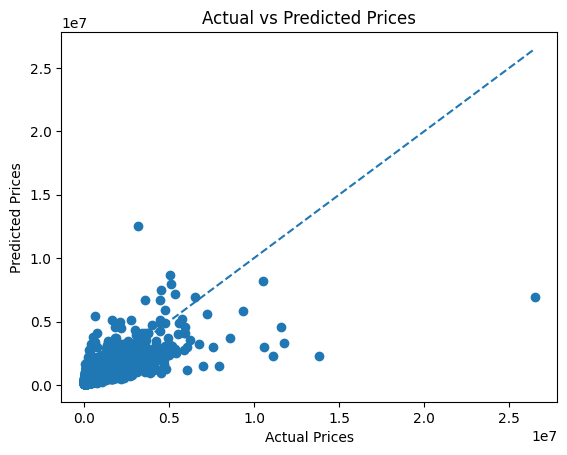

In [117]:
plt.figure()
plt.scatter(Y_test, y_pred)

# perfect prediction line
plt.plot(
    [Y_test.min(), Y_test.max()],
    [Y_test.min(), Y_test.max()],
    linestyle='--'
)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")

plt.show()